# FPR Visualization
This notebook loads the FPR `.npz` files for all methods across different `nT` and plots them as a line chart.

In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Setup paths relative to this notebook
notebook_dir = Path.cwd().resolve()
repo_root = notebook_dir.parent
results_dir = repo_root / "run_experiment" / "results"

In [6]:
# Parameters used in the experiments
p = 300
nS = 120
K = 5
lambda_sel = 0.6
lambda0 = 0.7
alpha = 0.05
nT_list = [50, 75, 100]

# Method configurations
methods = {
    'CoRT': {'name': 'CoRT-SI', 'color': '#ff0000'}, # Red
    'DS': {'name': 'DS', 'color': '#008000'},      # Green
    'naive': {'name': 'Naive', 'color': '#008080'}, # Teal
    'bonf': {'name': 'Bonferroni', 'color': '#800080'} # Purple
}

fpr_data = {method: [] for method in methods}

# Load data
for method in methods:
    for nT in nT_list:
        file_path = results_dir / f"{method}_fpr_p{p}_nS{nS}_nT{nT}_K{K}_lamsel{lambda_sel}_lam0{lambda0}.npz"
        if file_path.exists():
            data = np.load(file_path)
            if 'null_pvalues' in data:
                pvals = data['null_pvalues']
                if len(pvals) > 0:
                    fpr = np.mean(pvals <= alpha)
                    fpr_data[method].append(fpr)
                else:
                    fpr_data[method].append(np.nan)
            else:
                fpr_data[method].append(np.nan)
        else:
            fpr_data[method].append(np.nan)

# Print parsed data to verify
for method, fprs in fpr_data.items():
    print(f"{methods[method]['name']}: {fprs}")

CoRT-SI: [np.float64(0.01090909090909091), np.float64(0.06666666666666667), np.float64(0.0562015503875969)]
DS: [np.float64(0.043), np.float64(0.046890927624872576), np.float64(0.04354587869362364)]
Naive: [np.float64(0.40713536201469047), np.float64(0.41354723707664887), np.float64(0.3289036544850498)]
Bonferroni: [np.float64(0.0), np.float64(0.0), np.float64(0.0)]


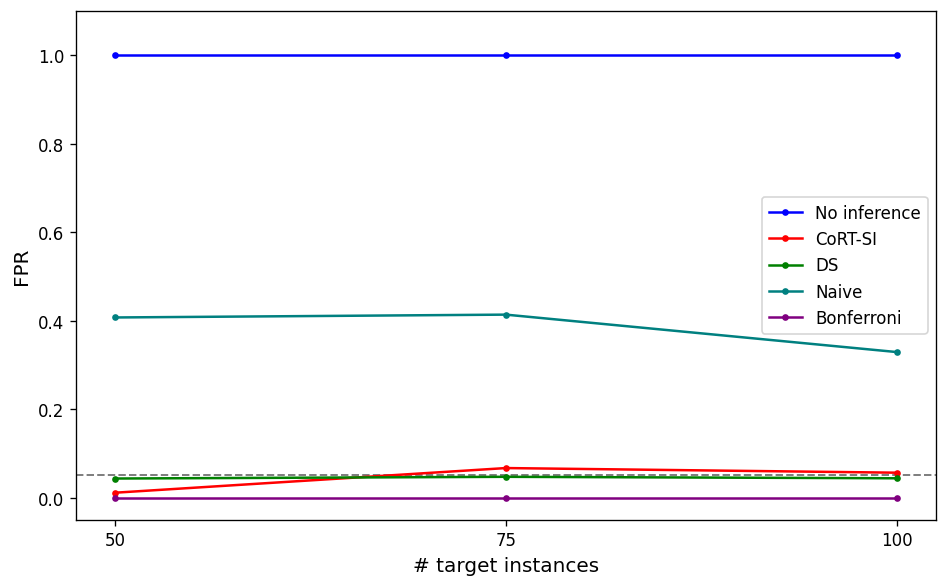

In [8]:
plt.figure(figsize=(8, 5), dpi=120)
plt.axhline(0.05, color='gray', linestyle='--', linewidth=1.2)

# Plot 'No inference' (baseline FPR = 1.0)
plt.plot(nT_list, [1.0]*len(nT_list), color='blue', marker='o', markersize=3, linewidth=1.5, label='No inference')

# Plot each method
for method, config in methods.items():
    plt.plot(nT_list, fpr_data[method], color=config['color'], marker='o', markersize=3, linewidth=1.5, label=config['name'])

plt.xlabel('# target instances', fontsize=12)
plt.ylabel('FPR', fontsize=12)
plt.xticks(nT_list)
plt.ylim(-0.05, 1.1)
plt.legend()
plt.tight_layout()

# Save figure
plt.savefig('results/fpr_nt_plot.pdf', dpi=300)
plt.savefig('results/fpr_nt_plot.png', dpi=300)
plt.show()